# 07 — Publication Quality
**Goal:** Produce figures good enough for journals, executive reports, or presentations.

Topics:
- DPI and export formats (PDF, PNG, SVG)
- Font control (size, family, weight)
- Color palettes for print (colorblind-safe)
- A reusable style template function
- Multi-panel figure for a report
- Exporting with `bbox_inches` and `pad_inches`

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

df = pd.read_csv('data/raw/funnel_data.csv', parse_dates=['date'])
print('Ready')

Ready


## 1. DPI and export formats

| Format | Best for | DPI |
|---|---|---|
| PNG | Web, slides, emails | 150–300 |
| PDF | Print, journals, LaTeX | vector (any DPI) |
| SVG | Web, editable in Illustrator | vector |
| EPS | Legacy journal submission | vector |

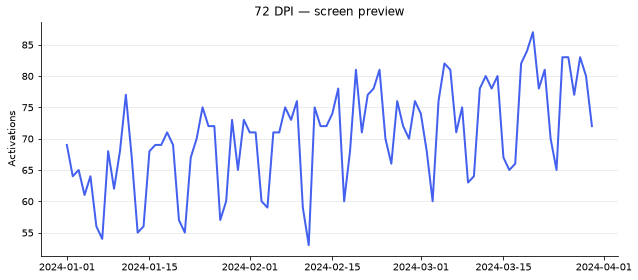

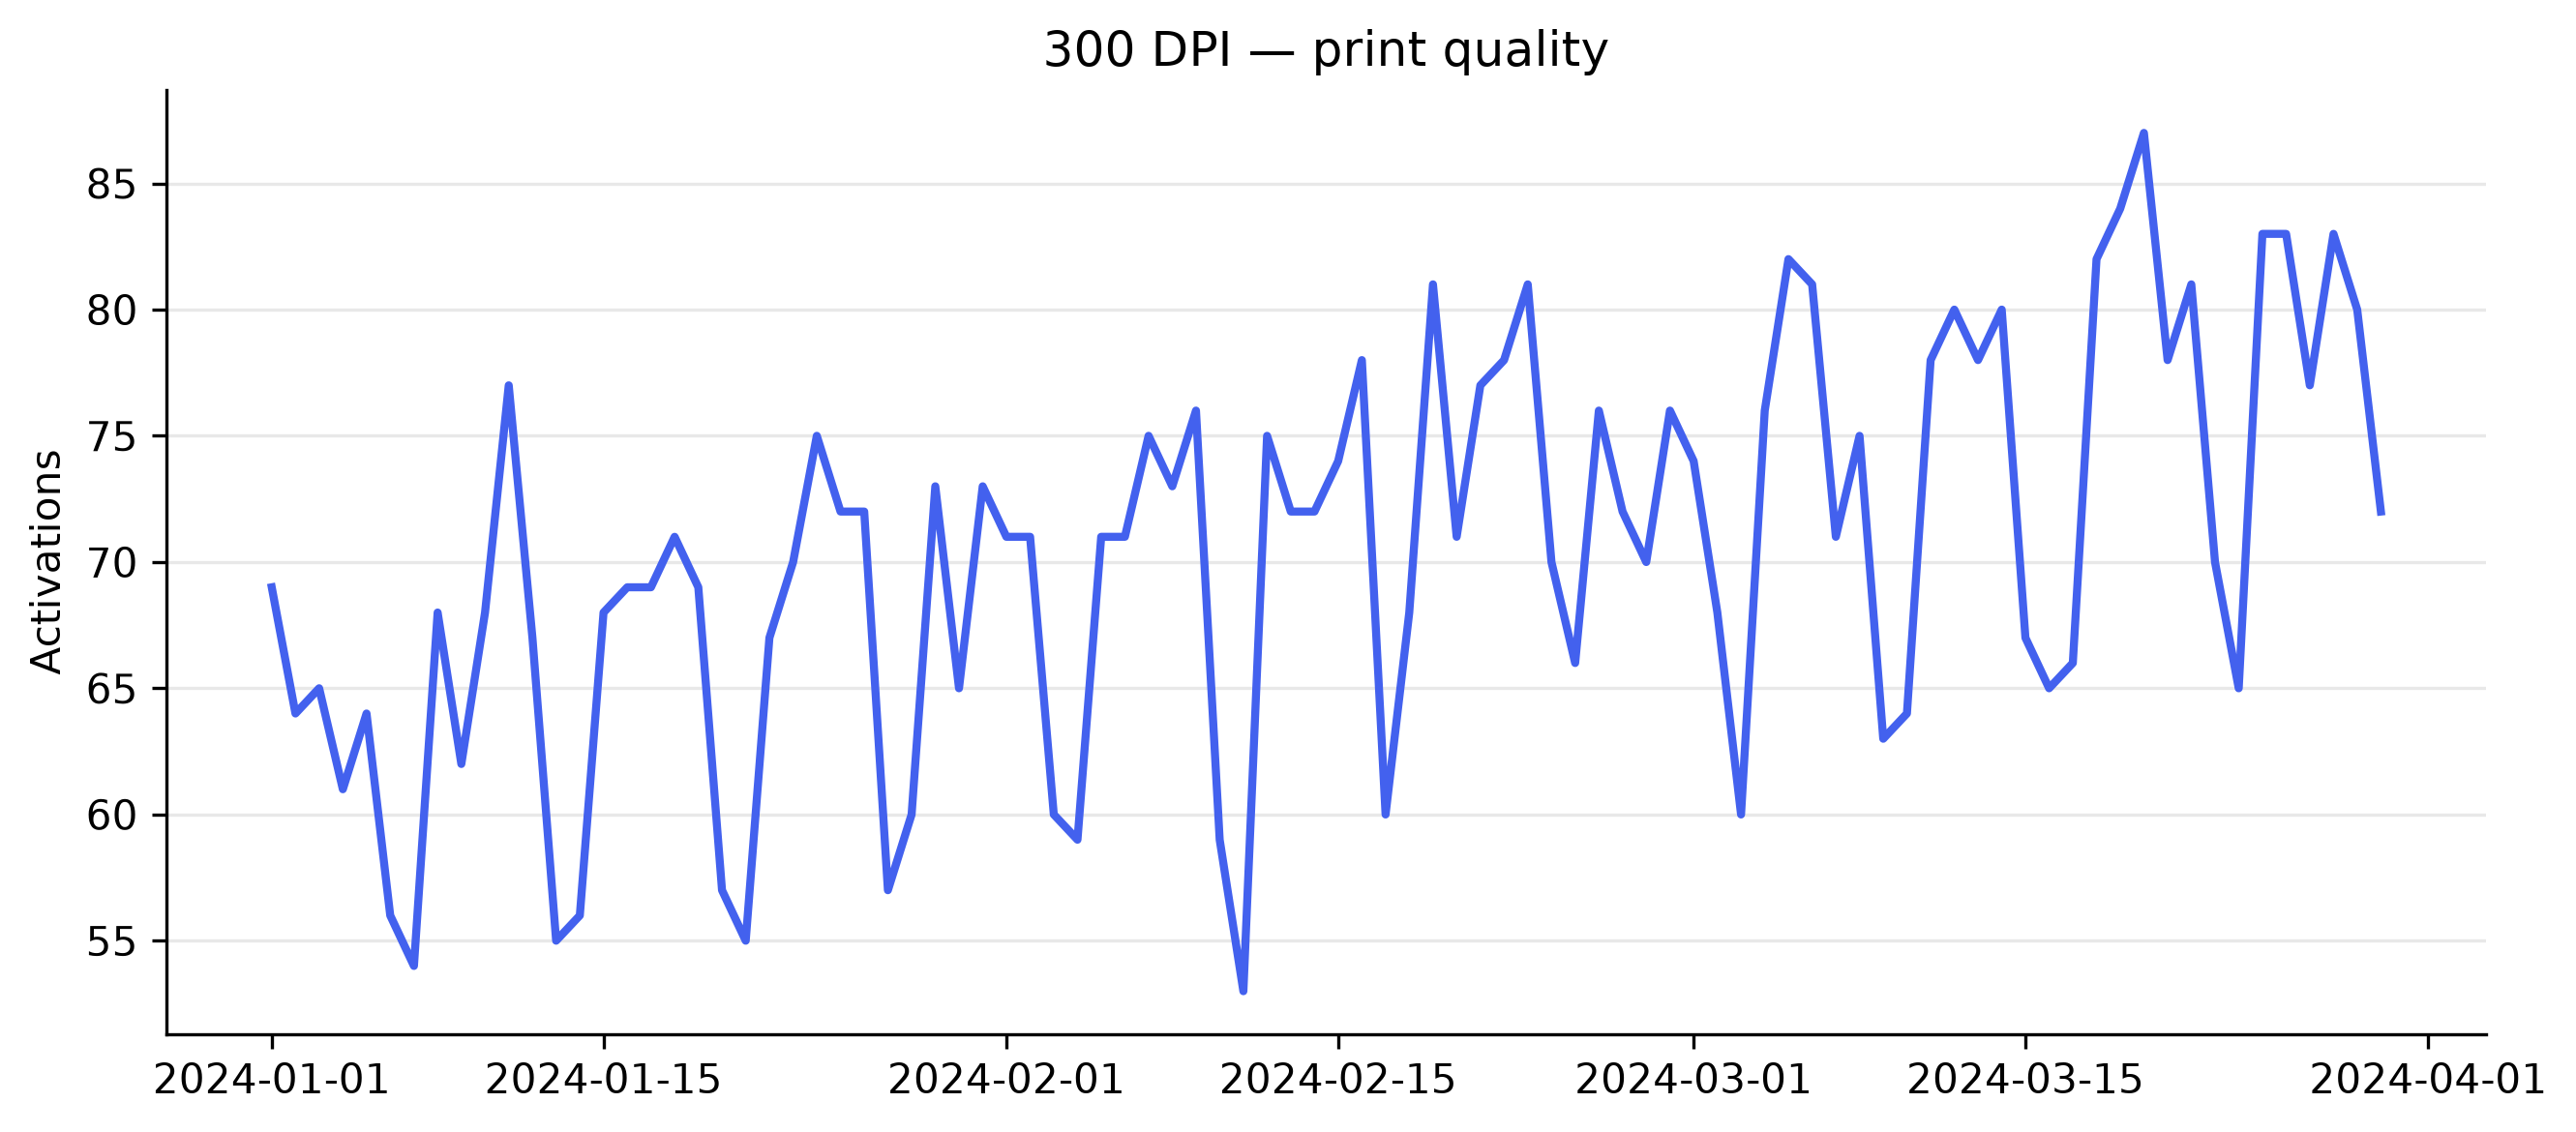

Exported: 72dpi PNG, 300dpi PNG, PDF, SVG


In [2]:
daily = df.groupby('date')['activacion_tarjeta'].sum().reset_index()

def make_sample_chart(ax, title):
    ax.plot(daily['date'], daily['activacion_tarjeta'], color='#4361ee', linewidth=2)
    ax.set_title(title)
    ax.set_ylabel('Activations')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
    ax.set_axisbelow(True)

# Screen quality (fast preview)
fig, ax = plt.subplots(figsize=(9, 4), dpi=72)
make_sample_chart(ax, '72 DPI — screen preview')
plt.tight_layout()
plt.savefig('data/export_72dpi.png', dpi=72, bbox_inches='tight')
plt.show()

# Print quality
fig, ax = plt.subplots(figsize=(9, 4), dpi=300)
make_sample_chart(ax, '300 DPI — print quality')
plt.tight_layout()
plt.savefig('data/export_300dpi.png', dpi=300, bbox_inches='tight')
plt.savefig('data/export_vector.pdf', bbox_inches='tight')  # PDF is always vector
plt.savefig('data/export_vector.svg', bbox_inches='tight')  # SVG too
plt.show()

print('Exported: 72dpi PNG, 300dpi PNG, PDF, SVG')

## 2. Font control
Font size hierarchy matters — title > axis labels > tick labels > annotations.

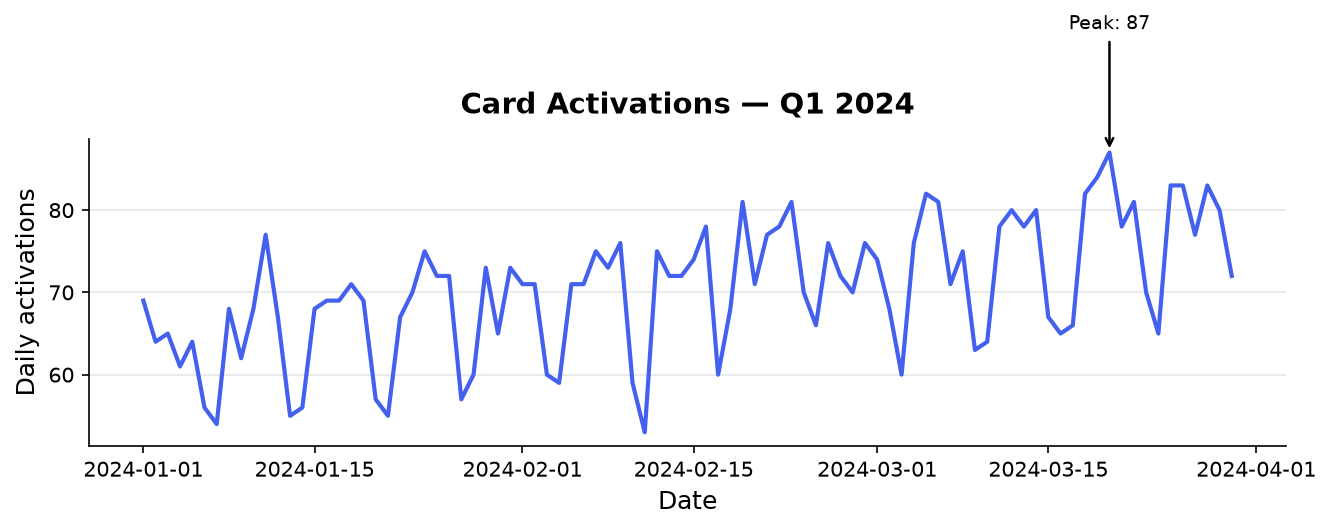

In [3]:
# Good font size hierarchy for a report figure
FONT_TITLE  = 14
FONT_LABEL  = 12
FONT_TICK   = 10
FONT_ANNOT  =  9

fig, ax = plt.subplots(figsize=(9, 4), dpi=150)

ax.plot(daily['date'], daily['activacion_tarjeta'],
        color='#4361ee', linewidth=2)

ax.set_title('Card Activations — Q1 2024',
             fontsize=FONT_TITLE, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=FONT_LABEL)
ax.set_ylabel('Daily activations', fontsize=FONT_LABEL)

# Control tick label size separately
ax.tick_params(axis='both', labelsize=FONT_TICK)

# Annotation in smaller font
peak_idx  = daily['activacion_tarjeta'].idxmax()
peak_date = daily.loc[peak_idx, 'date']
peak_val  = daily.loc[peak_idx, 'activacion_tarjeta']
ax.annotate(f'Peak: {peak_val:.0f}',
            xy=(peak_date, peak_val),
            xytext=(peak_date, peak_val + 15),
            ha='center', fontsize=FONT_ANNOT,
            arrowprops=dict(arrowstyle='->', lw=1.2))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 3. Colorblind-safe palette
~8% of men have color vision deficiency. Use palettes that work without relying on red vs green.

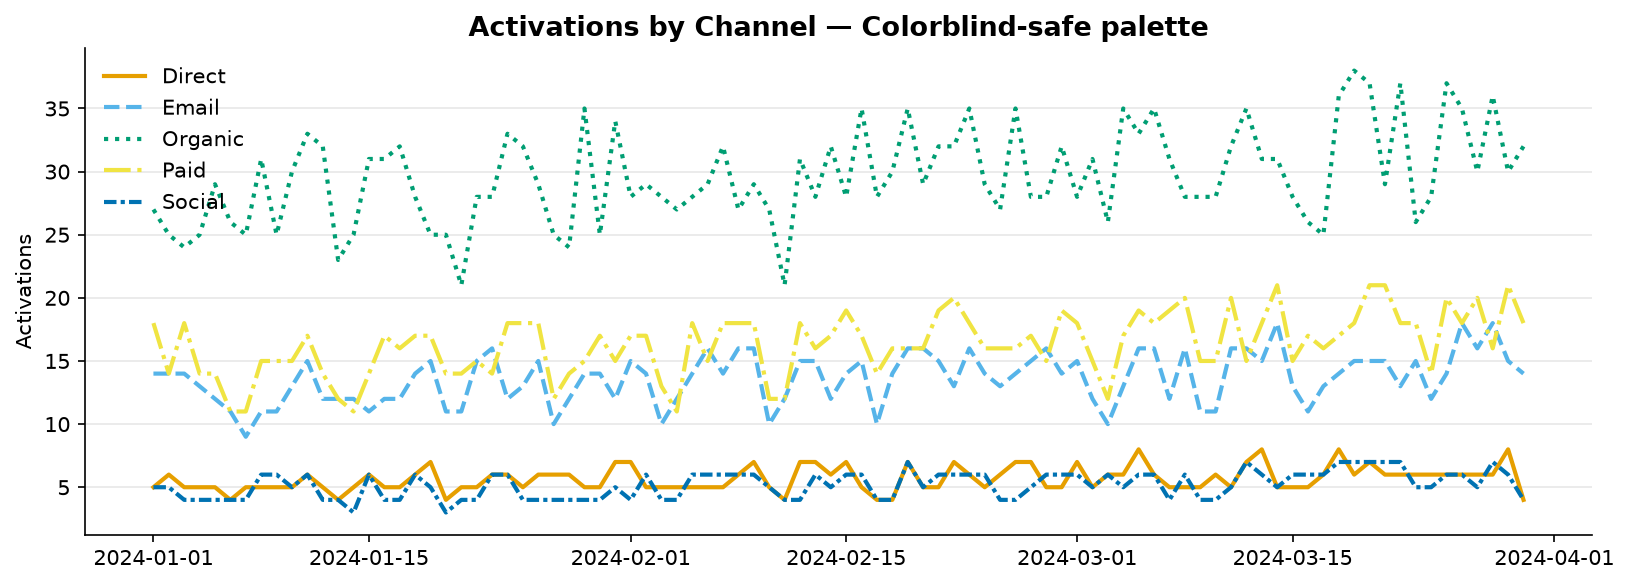

In [4]:
# Okabe-Ito palette — colorblind safe, recommended by Nature
OKABE_ITO = [
    '#E69F00',  # orange
    '#56B4E9',  # sky blue
    '#009E73',  # green
    '#F0E442',  # yellow
    '#0072B2',  # blue
    '#D55E00',  # vermillion
    '#CC79A7',  # purple-pink
]

channels = df['channel'].unique()
pivot = df.pivot_table(index='date', columns='channel',
                        values='activacion_tarjeta', aggfunc='sum').fillna(0)

fig, ax = plt.subplots(figsize=(11, 4), dpi=150)

for i, ch in enumerate(pivot.columns):
    # Different line styles reinforce the distinction beyond color
    styles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]
    ax.plot(pivot.index, pivot[ch],
            color=OKABE_ITO[i], linewidth=2,
            linestyle=styles[i % len(styles)],
            label=ch.capitalize())

ax.set_title('Activations by Channel — Colorblind-safe palette', fontsize=13, fontweight='bold')
ax.set_ylabel('Activations')
ax.legend(frameon=False, fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 4. Reusable style function
Define your own style once and apply it to any Axes — this is how you build consistent reports.

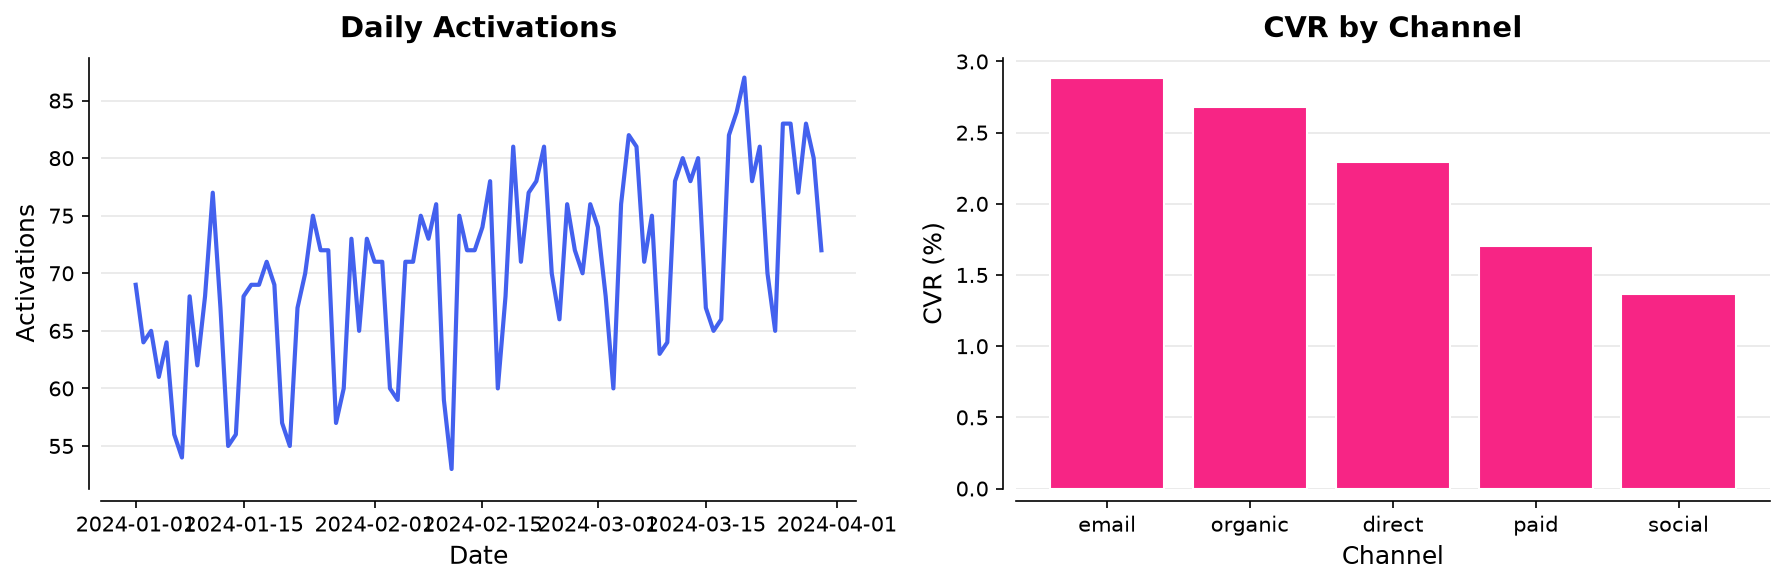

In [5]:
def apply_report_style(ax, title='', xlabel='', ylabel='',
                        title_size=14, label_size=12, tick_size=10):
    """Apply clean report styling to any Axes object."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 6))
    ax.spines['bottom'].set_position(('outward', 6))
    ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=tick_size)
    if title:  ax.set_title(title,  fontsize=title_size, fontweight='bold', pad=10)
    if xlabel: ax.set_xlabel(xlabel, fontsize=label_size)
    if ylabel: ax.set_ylabel(ylabel, fontsize=label_size)


# Now use it on any chart
channel_cvr = df.groupby('channel').apply(
    lambda g: g['activacion_tarjeta'].sum() / g['visita_landing'].sum() * 100
).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

ax1.plot(daily['date'], daily['activacion_tarjeta'], color='#4361ee', linewidth=2)
apply_report_style(ax1, title='Daily Activations', ylabel='Activations', xlabel='Date')

ax2.bar(channel_cvr.index, channel_cvr.values, color='#f72585', edgecolor='white')
apply_report_style(ax2, title='CVR by Channel', ylabel='CVR (%)', xlabel='Channel')

plt.tight_layout()
plt.show()

## 5. Full publication figure — multi-panel report

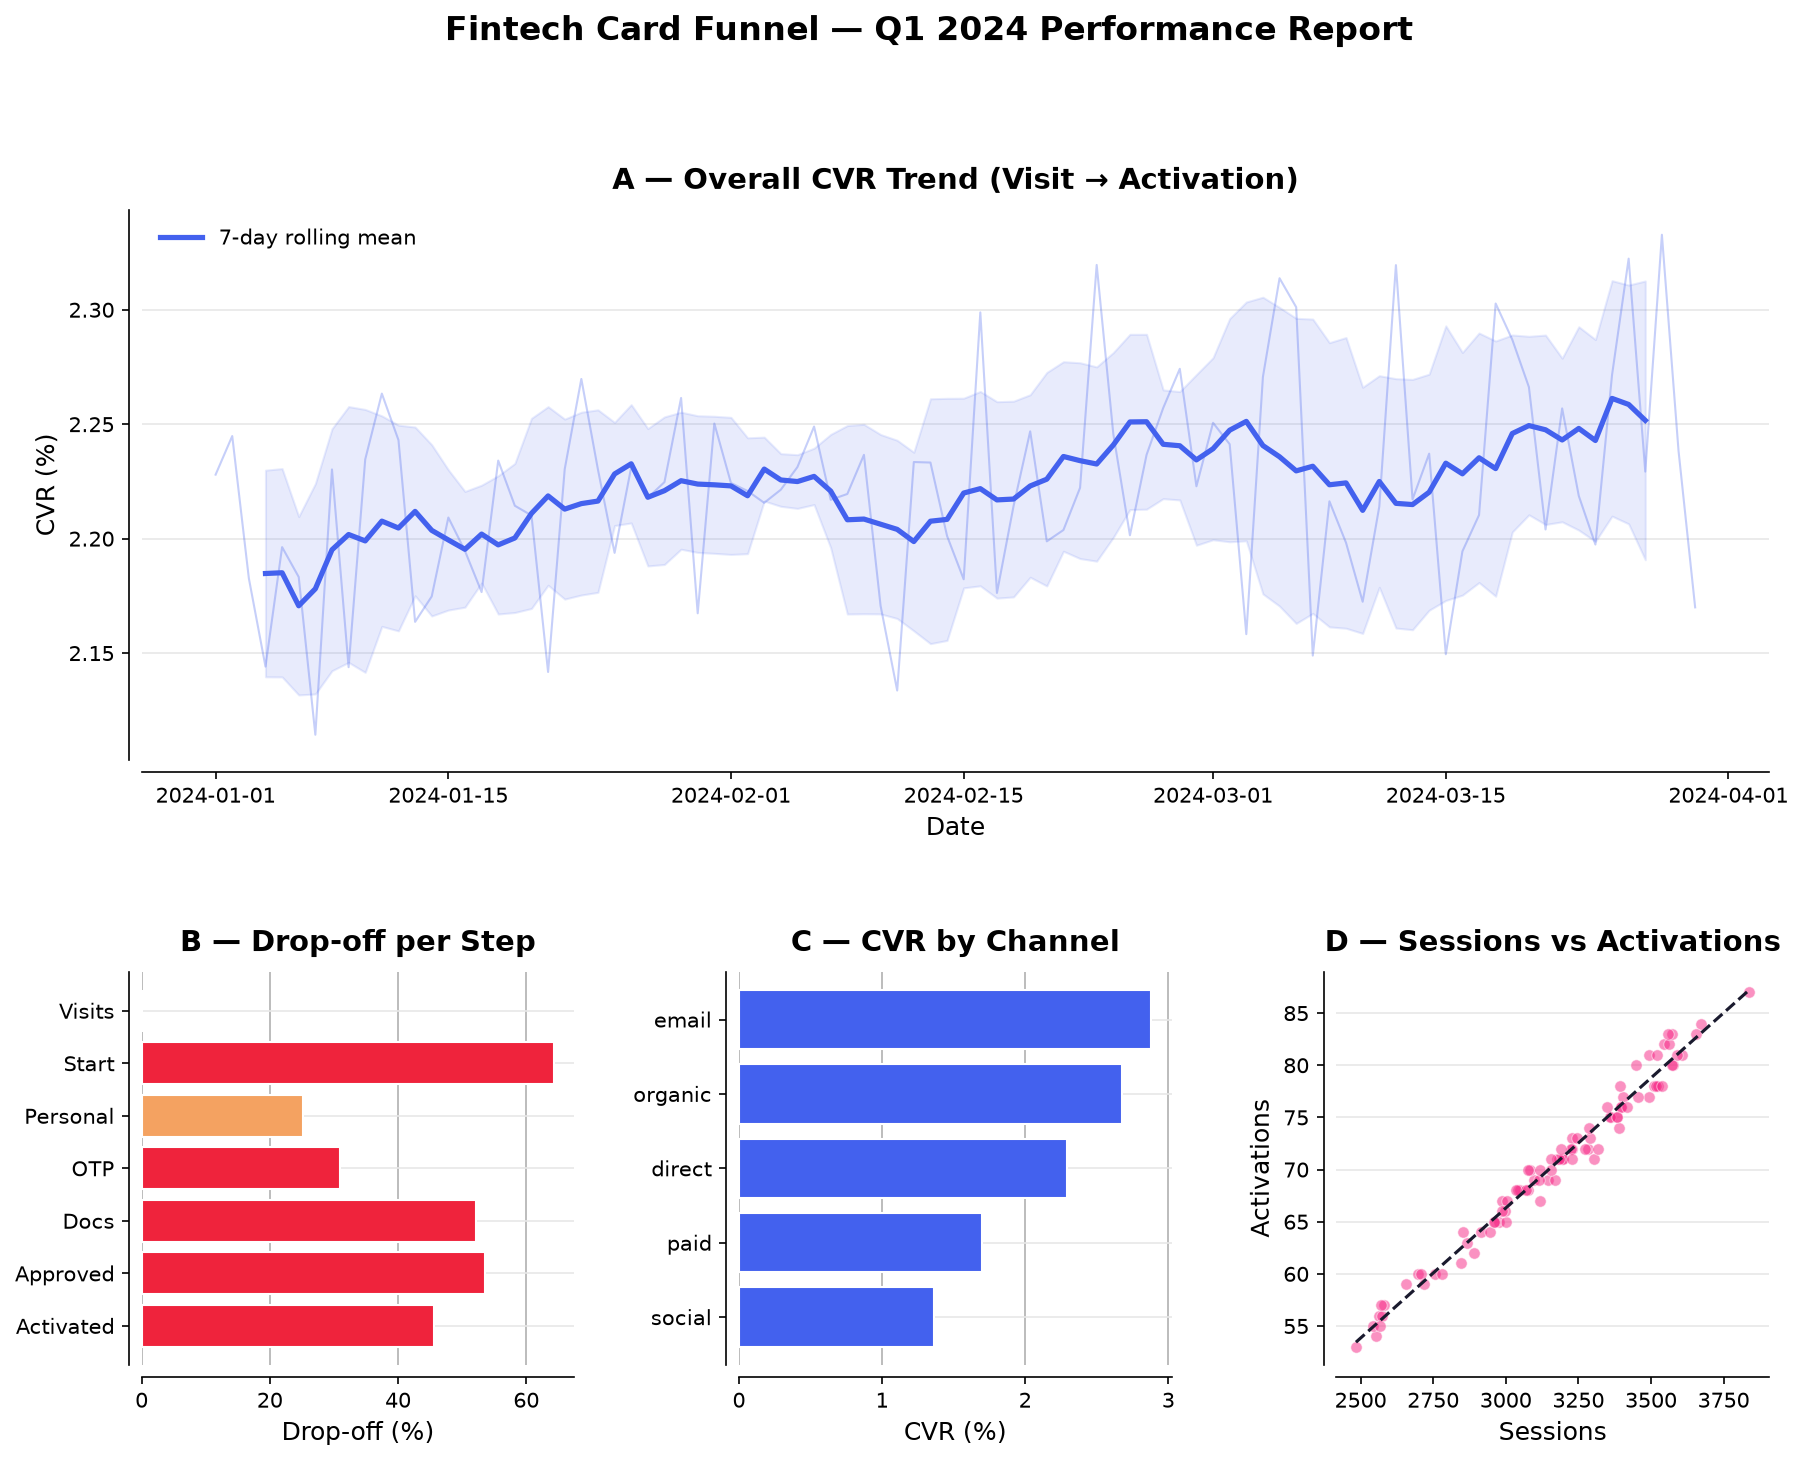

Saved: PDF and 300dpi PNG


In [6]:
# Pre-compute everything needed
daily_all = df.groupby('date').agg(
    sessions=('visita_landing', 'sum'),
    activations=('activacion_tarjeta', 'sum')
).reset_index()
daily_all['cvr'] = daily_all['activations'] / daily_all['sessions'] * 100
daily_all['roll_cvr'] = daily_all['cvr'].rolling(7, center=True).mean()

funnel_steps  = ['visita_landing','inicio_solicitud','datos_personales','otp',
                  'carga_documentos','aprobacion','activacion_tarjeta']
funnel_labels = ['Visits','Start','Personal','OTP','Docs','Approved','Activated']
totals = df[funnel_steps].sum()
drops  = [0] + [(totals[funnel_steps[i-1]] - totals[funnel_steps[i]]) /
                 totals[funnel_steps[i-1]] * 100
                 for i in range(1, len(funnel_steps))]

channel_cvr = df.groupby('channel').apply(
    lambda g: g['activacion_tarjeta'].sum() / g['visita_landing'].sum() * 100
).sort_values(ascending=True)

# --- Figure layout ---
fig = plt.figure(figsize=(14, 10), dpi=150)
gs  = gridspec.GridSpec(2, 3, height_ratios=[1.4, 1], hspace=0.45, wspace=0.38)

ax_top = fig.add_subplot(gs[0, :])      # wide top panel
ax_bl  = fig.add_subplot(gs[1, 0])
ax_bm  = fig.add_subplot(gs[1, 1])
ax_br  = fig.add_subplot(gs[1, 2])

# Panel A — CVR trend
ax_top.plot(daily_all['date'], daily_all['cvr'],
            color='#4361ee', alpha=0.3, linewidth=1)
ax_top.plot(daily_all['date'], daily_all['roll_cvr'],
            color='#4361ee', linewidth=2.5, label='7-day rolling mean')
ax_top.fill_between(daily_all['date'],
                     daily_all['roll_cvr'] - daily_all['cvr'].rolling(7, center=True).std(),
                     daily_all['roll_cvr'] + daily_all['cvr'].rolling(7, center=True).std(),
                     alpha=0.12, color='#4361ee')
ax_top.legend(frameon=False, fontsize=10)
apply_report_style(ax_top, title='A — Overall CVR Trend (Visit → Activation)',
                   ylabel='CVR (%)', xlabel='Date')

# Panel B — Funnel drop-off
drop_colors = ['#52b788' if d < 15 else '#f4a261' if d < 30 else '#ef233c'
               for d in drops]
ax_bl.barh(funnel_labels, drops, color=drop_colors, edgecolor='white')
apply_report_style(ax_bl, title='B — Drop-off per Step',
                   xlabel='Drop-off (%)', ylabel='')
ax_bl.invert_yaxis()
ax_bl.grid(axis='x')

# Panel C — CVR by channel
ax_bm.barh(channel_cvr.index, channel_cvr.values, color='#4361ee', edgecolor='white')
apply_report_style(ax_bm, title='C — CVR by Channel',
                   xlabel='CVR (%)', ylabel='')
ax_bm.grid(axis='x')

# Panel D — Sessions vs Activations scatter
ax_br.scatter(daily_all['sessions'], daily_all['activations'],
              color='#f72585', alpha=0.5, s=30, edgecolors='white', linewidth=0.5)
m, b = np.polyfit(daily_all['sessions'], daily_all['activations'], 1)
xl = np.linspace(daily_all['sessions'].min(), daily_all['sessions'].max(), 100)
ax_br.plot(xl, m*xl + b, color='#1a1a2e', linewidth=1.5, linestyle='--')
apply_report_style(ax_br, title='D — Sessions vs Activations',
                   xlabel='Sessions', ylabel='Activations')

fig.suptitle('Fintech Card Funnel — Q1 2024 Performance Report',
             fontsize=16, fontweight='bold', y=1.01)

plt.savefig('data/07_publication_report.pdf', bbox_inches='tight', pad_inches=0.2)
plt.savefig('data/07_publication_report.png', dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()
print('Saved: PDF and 300dpi PNG')

## Summary — publication checklist

Before exporting a figure for a report or journal:

- [ ] `dpi=300` for PNG, or use PDF/SVG for vector output
- [ ] Font hierarchy: title > labels > ticks > annotations
- [ ] Remove top and right spines
- [ ] Grid behind data (`ax.set_axisbelow(True)`)
- [ ] Colorblind-safe palette (Okabe-Ito or similar)
- [ ] Different line styles if lines overlap
- [ ] `bbox_inches='tight'` to remove whitespace
- [ ] Panel labels (A, B, C...) for multi-panel figures
- [ ] Legend outside the plot if it covers data
- [ ] `savefig` called before `plt.show()`

---
## Course complete

| Notebook | Topic |
|---|---|
| 01 | Foundations — Figure, Axes, OO style |
| 02 | Styling — colors, spines, rcParams |
| 03 | Chart types — when to use each |
| 04 | Subplots & layouts — GridSpec, insets |
| 05 | Annotations — text, arrows, LaTeX |
| 06 | Statistical plots — CI, regression, heatmap |
| 07 | Publication quality — export, fonts, style function |